In [1]:
import numpy as np
import jax
import jax.numpy as jnp

jax.config.update("jax_platform_name", "cpu")
from jax import vmap, jit
import matplotlib.pyplot as plt
import joblib
from qdots_qll.models import game
from qdots_qll import all_funcs
import seaborn as sns
import pandas as pd
import scipy
from functools import reduce
import os
import re
from scipy.stats import binned_statistic

import seaborn as sns


import matplotlib.font_manager as font_manager

import equinox as eqx

# from matplotlib import rcParams
from scipy.stats import binned_statistic


font = {"family": "Inter"}  # , 'weight': 'normal', 'size': 12}

# Aplica la fuente definida a Matplotlib
plt.rc("font", **font)

sns.set_palette("colorblind")

In [2]:
names_true = [
    "$\\gamma ( + \\eta)$",
    "$S ( - \\eta)$",
    "$S ( +\\eta)$",
]
names_hat = [
    "$\\hat{\\gamma} ( + \\eta)$",
    "$\\hat{S} ( - \\eta)$",
    "$\\hat{S} ( +\\eta)$",
]

In [3]:
def compute_mean_one_run(cum_times_i, cov_arr_i, limites_bins):
    indices_bins = np.digitize(cum_times_i, limites_bins)
    means = np.array(
        [
            np.nanmean(cov_arr_i[indices_bins == i], axis=0)
            for i in range(1, len(limites_bins))
        ]
    )

    std_devs = np.array(
        [
            np.nanstd(cov_arr_i[indices_bins == i], axis=0)
            for i in range(1, len(limites_bins))
        ]
    )
    return means, std_devs


def get_binned_results_from_runs(
    times_array,
    cov_array,
    est_array,
    bin_step,
):
    dims_cov = cov_array[:, 1:].shape[2:]
    dims_est = est_array[:, 1:].shape[2:]

    cum_times = np.array(times_array[:, 1:]).cumsum(axis=1)
    cum_times_flatten = cum_times.flatten()
    cov_flatten = np.array(cov_array[:, 1:]).reshape(-1, *dims_cov)
    est_flatten = np.array(est_array[:, 1:]).reshape(-1, *dims_est)

    bins = np.arange(
        cum_times_flatten.min(), cum_times_flatten.max() + 1, bin_step
    )

    cov_mean_list = []
    cov_std_list = []

    for i in range(dims_cov[0]):
        cov_mean_row_list = []
        cov_std_row_list = []

        for j in range(dims_cov[1]):

            cov_mean_row_list.append(
                binned_statistic(
                    cum_times_flatten,
                    cov_flatten[:, i, j],
                    statistic="mean",
                    bins=bins,
                )[0]
            )
            cov_std_row_list.append(
                binned_statistic(
                    cum_times_flatten,
                    cov_flatten[:, i, j],
                    statistic="std",
                    bins=bins,
                )[0]
            )
        cov_mean_list.append(cov_mean_row_list)
        cov_std_list.append(cov_std_row_list)
    cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
    cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

    est_mean_list = []
    est_std_list = []

    for i in range(dims_est[0]):

        est_mean_list.append(
            binned_statistic(
                cum_times_flatten,
                est_flatten[
                    :,
                    i,
                ],
                statistic="mean",
                bins=bins,
            )[0]
        )
        est_std_list.append(
            binned_statistic(
                cum_times_flatten,
                est_flatten[
                    :,
                    i,
                ],
                statistic="std",
                bins=bins,
            )[0]
        )
    est_mean_list = np.array(est_mean_list).transpose(1, 0)
    est_std_list = np.array(est_std_list).transpose(1, 0)

    cum_times_binned, _, _ = binned_statistic(
        cum_times_flatten, cum_times_flatten, statistic="mean", bins=bins
    )
    return (
        cum_times_binned,
        cov_mean_list,
        cov_std_list,
        est_mean_list,
        est_std_list,
    )

In [4]:
jax.scipy.stats.binned_statistic?

Object `jax.scipy.stats.binned_statistic` not found.


In [32]:
def results_bin_single_run(times, covs, ests, no_bins):

    cum_times = np.array(times[1:]).cumsum()
    # bins = np.linspace(cum_times.min(), cum_times.max() + 1, no_bins)
    dims_cov = covs.shape[-2:]
    dims_est = ests.shape[-1:]

    cov_mean_list = []
    cov_std_list = []

    for i in range(dims_cov[0]):
        cov_mean_row_list = []
        cov_std_row_list = []

        for j in range(dims_cov[1]):

            cov_mean_row_list.append(
                binned_statistic(
                    cum_times,
                    covs[1:, i, j],
                    statistic="mean",
                    bins=no_bins,
                )[0]
            )
            cov_std_row_list.append(
                binned_statistic(
                    cum_times,
                    covs[1:, i, j],
                    statistic="std",
                    bins=no_bins,
                )[0]
            )
        cov_mean_list.append(cov_mean_row_list)
        cov_std_list.append(cov_std_row_list)
    cov_mean_list = np.array(cov_mean_list).transpose(2, 1, 0)
    cov_std_list = np.array(cov_std_list).transpose(2, 1, 0)

    est_mean_list = []
    est_std_list = []

    for i in range(dims_est[0]):

        est_mean_list.append(
            binned_statistic(
                cum_times,
                ests[
                    1:,
                    i,
                ],
                statistic="mean",
                bins=no_bins,
            )[0]
        )
        est_std_list.append(
            binned_statistic(
                cum_times,
                ests[
                    1:,
                    i,
                ],
                statistic="std",
                bins=no_bins,
            )[0]
        )
    est_mean_list = np.array(est_mean_list).transpose(1, 0)
    est_std_list = np.array(est_std_list).transpose(1, 0)

    cum_times_binned, _, _ = binned_statistic(
        cum_times, cum_times, statistic="mean", bins=no_bins
    )
    times_binned, _, _ = binned_statistic(
        cum_times, np.array(times[1:]), statistic="mean", bins=no_bins
    )
    return (
        times_binned,
        cum_times_binned,
        cov_mean_list,
        cov_std_list,
        est_mean_list,
        est_std_list,
    )

In [8]:
binned_statistic?

Signature: binned_statistic(x, values, statistic='mean', bins=10, range=None)
Docstring:
Compute a binned statistic for one or more sets of data.

This is a generalization of a histogram function.  A histogram divides
the space into bins, and returns the count of the number of points in
each bin.  This function allows the computation of the sum, mean, median,
or other statistic of the values (or set of values) within each bin.

Parameters
----------
x : (N,) array_like
    A sequence of values to be binned.
values : (N,) array_like or list of (N,) array_like
    The data on which the statistic will be computed.  This must be
    the same shape as `x`, or a set of sequences - each the same shape as
    `x`.  If `values` is a set of sequences, the statistic will be computed
    on each independently.
statistic : string or callable, optional
    The statistic to compute (default is 'mean').
    The following statistics are available:

      * 'mean' : compute the mean of values for points

In [20]:
i = 4
k = 4

run = runs[i]

covs = run.cov_array[k]
ests = run.estimates_array[k]
times = run.times_array[k]

In [21]:
times

Array([0.       , 8.039744 , 8.192319 , ..., 7.756558 , 7.6693416,
       7.6596985], dtype=float32)

In [33]:
i = 4
run = runs[i]

k = 0

times_list = []
cumtimes_list = []
covmean_list = []
covstd_list = []
estmean_list = []
eststd_list = []

no_runs = run.iteration.shape[0]
for k in range(no_runs):
    covs = run.cov_array[k]
    ests = run.estimates_array[k]
    times = run.times_array[k]

    re = results_bin_single_run(times, covs, ests, 2300)

    times_list.append(re[0])
    cumtimes_list.append(re[1])
    covmean_list.append(re[2])
    covstd_list.append(re[3])
    estmean_list.append(re[4])
    eststd_list.append(re[5])

times_list = np.array(times_list).mean(axis=0)
cumtimes_list = np.array(cumtimes_list).mean(axis=0)
covmean_list = np.array(covmean_list).mean(axis=0)
covstd_list = np.array(covstd_list).mean(axis=0)
estmean_list = np.array(estmean_list).mean(axis=0)
eststd_list = np.array(eststd_list).mean(axis=0)

In [34]:
times_list

array([8.12151613, 8.04227452, 8.00601687, ..., 7.78925715, 7.71937027,
       7.76419167])

[]

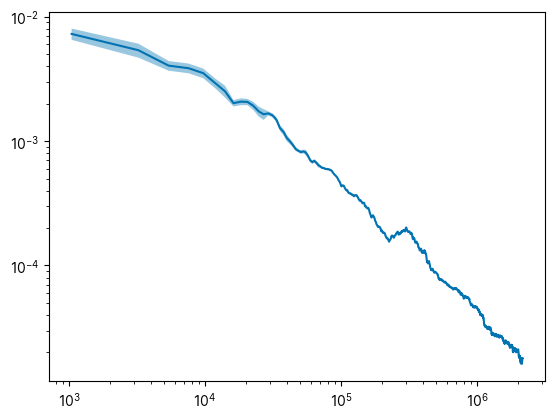

In [136]:
plt.plot(cumtimes_list, covmean_list[:, 0, 0])
plt.fill_between(
    cumtimes_list,
    covstd_list[:, 0, 0] + covmean_list[:, 0, 0],
    -covstd_list[:, 0, 0] + covmean_list[:, 0, 0],
    alpha=0.4,
)

plt.loglog()

In [41]:
_, _, _, a, b = get_binned_results_from_runs(
    run.times_array, run.cov_array, run.estimates_array, 200
)

# for

In [9]:
filenames = sorted(os.listdir("../results_cluster/one_qdot/"))
filenames = ["../results_cluster/one_qdot/" + i for i in filenames]
job_filenames = list(filter(re.compile(".*job").match, filenames))
log_filenames = list(filter(re.compile(".*log").match, filenames))

runs = [joblib.load(i) for i in job_filenames]

In [10]:
log_filenames

['../results_cluster/one_qdot/run_2024-03-28_16:43:31.log',
 '../results_cluster/one_qdot/run_2024-03-28_16:45:02.log',
 '../results_cluster/one_qdot/run_2024-03-28_16:45:32.log',
 '../results_cluster/one_qdot/run_2024-03-28_17:20:33.log',
 '../results_cluster/one_qdot/run_2024-03-28_18:03:55.log',
 '../results_cluster/one_qdot/run_2024-04-01_11:11:06.log']

In [11]:
legend_array = [
    "Random",
    "Max det(FIM)",
    "Max trace(FIM)",
    "Random",
    "Max det(FIM)",
    "Max trace(FIM)",
]

In [47]:
# Now we are gonna compute the fisher information with the expected particle for each case

In [37]:
from qdots_qll.models.models_scratch_for_drafting import (
    SingleQDot3Params,
)
from qdots_qll.utils.povms import sigmas_povm
import qutip as qt

ground_state_qdot = jnp.array(qt.ket2dm(qt.basis(2, 0))).flatten()
model = SingleQDot3Params(POVM_array=jnp.array(sigmas_povm))

m = model

true_pars = jnp.array([0.35833, 0.053851, -0.333695])

In [205]:
from qdots_qll.distributions import (
    initialize_particle_locations_normal_prior,
    est_cov,
)


bnds = np.array([[0.01, 0.9], [0.001, 0.22], [-0.01, -0.9]])
sigmasprior = 5
covs_prior = jnp.diagflat(jnp.std(bnds, axis=1) / sigmasprior) ** 2
mus_prior = jnp.mean(bnds, axis=1)

print(f"mus prior: {mus_prior}")
print(f"covs prior: {np.diag(covs_prior)}")

I = np.diag(np.diag(1 / covs_prior))
print(I)


seed = 10
key = jax.random.PRNGKey(seed)
no_particles = 500

init_locations = initialize_particle_locations_normal_prior(
    key, no_of_particles=no_particles, boundaries=bnds, sigmas=5
)

init_weights = jnp.ones(no_particles) / no_particles

I = np.linalg.inv(est_cov(init_locations, init_weights))
print(I)

mus prior: [ 0.45499998  0.1105     -0.45499998]
covs prior: [0.007921   0.00047961 0.007921  ]
[[ 126.24669    0.         0.     ]
 [   0.      2085.0273     0.     ]
 [   0.         0.       126.24669]]
[[ 120.353195  -46.572266  -20.24047 ]
 [ -46.573097 2247.4316     10.711998]
 [ -20.240492   10.712867  123.836754]]


In [206]:
est_cov(init_locations, init_weights)

Array([[ 8.6095035e-03,  1.7177314e-04,  1.3923198e-03],
       [ 1.7177686e-04,  4.4856314e-04, -1.0725111e-05],
       [ 1.3923198e-03, -1.0728836e-05,  8.3036423e-03]], dtype=float32)

In [207]:
runs[0]

Run(
  iteration=i32[20],
  key=u32[20,2],
  time=f32[20],
  weights=f32[20,500],
  particles_locations=f32[20,500,3],
  times_array=f32[20,10000],
  estimates_array=f32[20,10000,3],
  cov_array=f32[20,10000,3,3],
  max_iterations=i32[20],
  min_iterations=i32[20],
  std_threshold=f32[20]
)

In [209]:
# # i = 4

# results_binned = []

# for i in range(len(runs)):
#     (
#         cum_times_binned,
#         cov_mean_list,
#         cov_std_list,
#         est_mean_list,
#         est_std_list,
#     ) = get_binned_results_from_runs(
#         runs[i].times_array, runs[i].cov_array, runs[i].estimates_array, 1000
#     )

#     cov_dict = {
#         "times": cum_times_binned,
#         "covmean": cov_mean_list,
#         "covstd": cov_std_list,
#         "estmean": est_mean_list,
#         "eststd": est_std_list,
#     }
#     results_binned.append(cov_dict)


# for i in range(len(results_binned)):
#     cumtimes = results_binned[i]["times"]
#     times = np.diff(cumtimes, prepend=0)
#     covmeans = results_binned[i]["covmean"]
#     estmeans = results_binned[i]["estmean"]

#     fisher_information_each_time = np.array(
#         jax.vmap(
#             lambda particle, time: m.fim(particle, time, ground_state_qdot),
#             in_axes=(0, 0),
#         )(estmeans, times)
#     )

#     det_fisher_information_each_time = np.array(
#         jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
#     )

#     results_binned[i]["fishermeans"] = fisher_information_each_time
#     results_binned[i]["fisherdets"] = det_fisher_information_each_time

#     det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
#     results_binned[i]["covdet"] = det_covs

In [210]:
re[3].shape

(1000, 3, 3)

In [211]:
covstd_list

array([[[1.42784804e-03, 2.08153055e-04, 1.08212104e-03],
        [2.08153081e-04, 9.25459508e-05, 2.07208419e-04],
        [1.08212080e-03, 2.07208456e-04, 1.83211806e-03]],

       [[1.41790351e-03, 2.43439923e-04, 9.86580847e-04],
        [2.43440009e-04, 1.69287060e-04, 3.31531326e-04],
        [9.86580880e-04, 3.31531375e-04, 1.62301585e-03]],

       [[1.30653504e-03, 2.77969730e-04, 5.59918874e-04],
        [2.77969757e-04, 2.26585545e-04, 3.70594208e-04],
        [5.59918990e-04, 3.70594224e-04, 1.25745437e-03]],

       ...,

       [[2.11437373e-05, 3.29283477e-06, 9.41954241e-06],
        [3.29285138e-06, 1.26242103e-05, 1.83927806e-05],
        [9.41949383e-06, 1.83927500e-05, 2.58290226e-05]],

       [[2.17627355e-05, 3.24336606e-06, 9.27923214e-06],
        [3.24338371e-06, 1.28288542e-05, 1.86875978e-05],
        [9.27898614e-06, 1.86876134e-05, 2.62876691e-05]],

       [[2.19424772e-05, 3.31236026e-06, 9.29696779e-06],
        [3.31236638e-06, 1.29815534e-05, 1.890776

In [212]:
results_binned = []

no_bins = 3000
for i in range(len(runs)):
    run = runs[i]

    times_list = []
    cumtimes_list = []
    covmean_list = []
    covstd_list = []
    estmean_list = []
    eststd_list = []

    no_runs = run.iteration.shape[0]
    for k in range(no_runs):
        covs = run.cov_array[k]
        ests = run.estimates_array[k]
        times = run.times_array[k]

        re = results_bin_single_run(times, covs, ests, no_bins)

        times_list.append(re[0])
        cumtimes_list.append(re[1])
        covmean_list.append(re[2])
        covstd_list.append(re[3])
        estmean_list.append(re[4])
        eststd_list.append(re[5])

    times_list = np.array(times_list).mean(axis=0)
    cumtimes_list = np.array(cumtimes_list).mean(axis=0)
    covstd_list = np.array(covmean_list).std(axis=0)
    covmean_list = np.array(covmean_list).mean(axis=0)

    # covstd_list = np.array(covstd_list).mean(axis=0)

    eststd_list = np.array(estmean_list).std(axis=0)
    estmean_list = np.array(estmean_list).mean(axis=0)

    # eststd_list = np.array(eststd_list).mean(axis=0)

    # (
    #     cum_times_binned,
    #     cov_mean_list,
    #     cov_std_list,
    #     est_mean_list,
    #     est_std_list,
    # ) = get_binned_results_from_runs(
    #     runs[i].times_array, runs[i].cov_array, runs[i].estimates_array, 1000
    # )

    cov_dict = {
        "times": times_list,
        "cumtimes": cumtimes_list,
        "covmean": covmean_list,
        "covstd": covstd_list,
        "estmean": estmean_list,
        "eststd": eststd_list,
    }
    results_binned.append(cov_dict)


for i in range(len(results_binned)):
    times = results_binned[i]["times"]
    # times = np.diff(cumtimes, prepend=0)
    covmeans = results_binned[i]["covmean"]
    estmeans = results_binned[i]["estmean"]

    fisher_information_each_time = np.array(
        jax.vmap(
            lambda particle, time: m.fim(particle, time, ground_state_qdot),
            in_axes=(0, 0),
        )(estmeans, times)
    )

    det_fisher_information_each_time = np.array(
        jax.vmap(lambda f: jnp.linalg.det(f))(fisher_information_each_time)
    )

    results_binned[i]["fishermeans"] = fisher_information_each_time
    results_binned[i]["fisherdets"] = det_fisher_information_each_time

    det_covs = np.array(jax.vmap(lambda f: jnp.linalg.det(f))(covmeans))
    results_binned[i]["covdet"] = det_covs

In [213]:
# Plot here the optimal determinant

best_t = runs[4].times_array.mean()
true_inv_FIM = jnp.linalg.inv(m.fim(true_pars, best_t, ground_state_qdot))
true_FIM = m.fim(true_pars, best_t, ground_state_qdot)

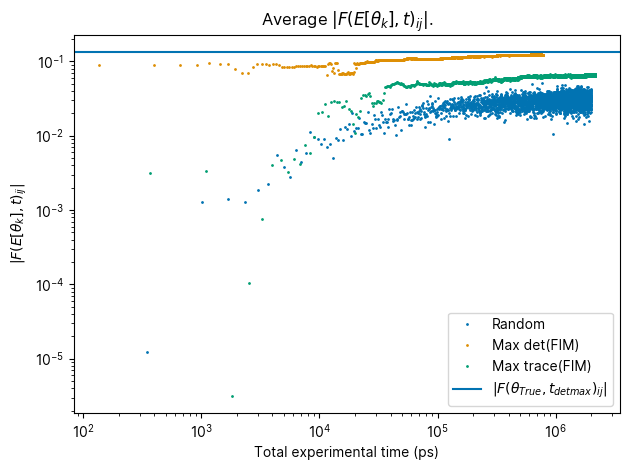

In [238]:
for i in range(3, 6, 1):
    # print(legend_array[i])
    plt.plot(
        results_binned[i]["cumtimes"],
        results_binned[i]["fisherdets"],
        ".",
        label=legend_array[i],
        ms=2,
    )
plt.axhline(
    jnp.linalg.det(true_FIM),
    label="$|F( \\theta_{True}, t_{det max})_{ij} | $",
)
plt.legend()
plt.loglog()

plt.xlabel("Total experimental time (ps)")
plt.ylabel("$|F( E[\\theta_k], t)_{ij} | $")
plt.title("Average $|F( E[\\theta_k], t)_{ij} | $.")
plt.tight_layout()
plt.show()

In [250]:
runs[0]

Run(
  iteration=i32[20],
  key=u32[20,2],
  time=f32[20],
  weights=f32[20,500],
  particles_locations=f32[20,500,3],
  times_array=f32[20,10000],
  estimates_array=f32[20,10000,3],
  cov_array=f32[20,10000,3,3],
  max_iterations=i32[20],
  min_iterations=i32[20],
  std_threshold=f32[20]
)

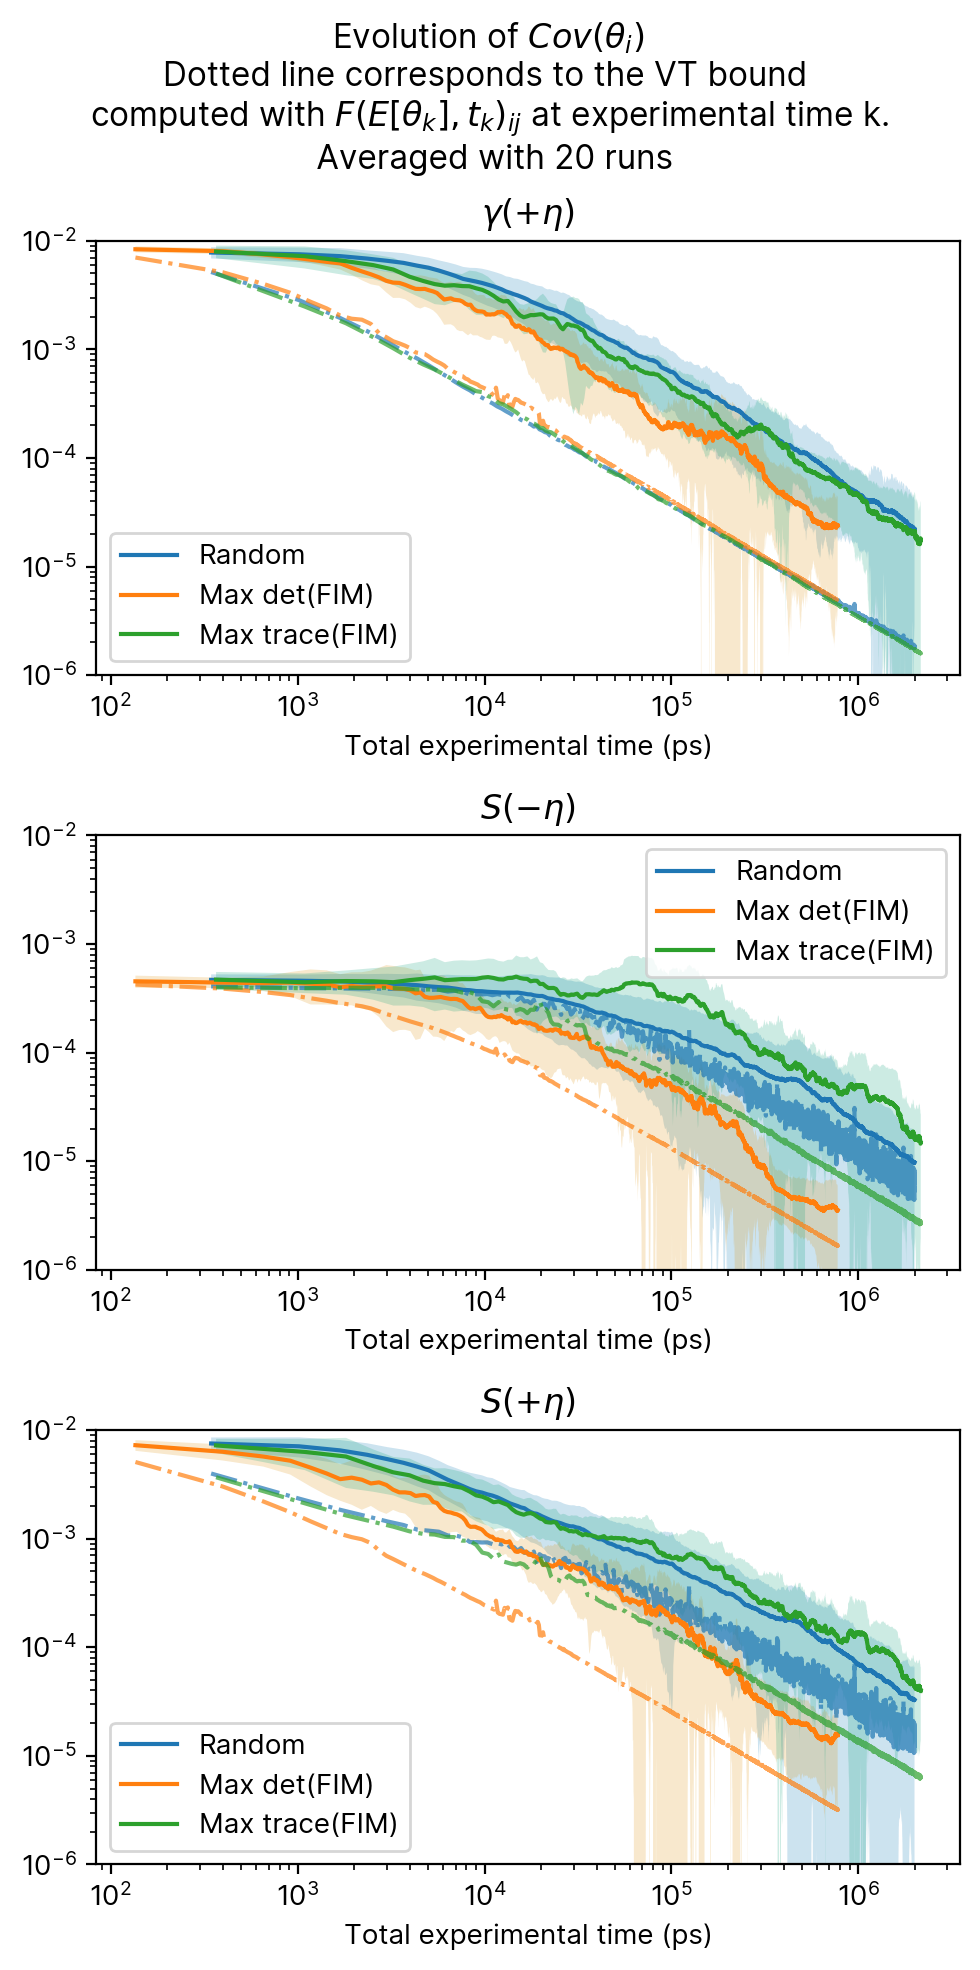

In [251]:
fig, axs = plt.subplots(3, 1, figsize=(5, 10), dpi=200)

colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
]

for j, ax in enumerate(axs.flatten()):
    for i in range(3, 6, 1):
        ax.set_title(names_true[j])
        ax.set_xlabel("Total experimental time (ps)")
        ax.set_ylim(1e-6, 1e-2)
        ax.plot(
            results_binned[i]["cumtimes"],
            results_binned[i]["covmean"][:, j, j],
            "-",
            color=colors[i - 3],
            label=legend_array[i],
        )

        ax.fill_between(
            results_binned[i]["cumtimes"],
            results_binned[i]["covmean"][:, j, j]
            + results_binned[i]["covstd"][:, j, j],
            results_binned[i]["covmean"][:, j, j]
            - results_binned[i]["covstd"][:, j, j],
            alpha=0.2,
        )

        ax.plot(
            results_binned[i]["cumtimes"],
            jax.vmap(
                (
                    lambda T, EF, I: 1
                    / T
                    * 1
                    * jnp.linalg.inv(1 * (1 * EF + 1 * I / T))
                ),
                in_axes=(0, 0, None),
            )(
                results_binned[i]["cumtimes"],
                results_binned[i]["fishermeans"],
                I,
            )[
                :, j, j
            ],
            "-.",
            ms=3,
            alpha=0.7,
            color=colors[i - 3],
        )

        ax.loglog()
    # ax.plot(
    #     results_binned[i]["cumtimes"],
    #     jax.vmap(
    #         (
    #             lambda T, EF, I: 1
    #             / T
    #             * 1
    #             * jnp.linalg.inv(1 * (1 * EF + 1 * I / T))
    #         ),
    #         in_axes=(0, None, None),
    #     )(results_binned[i]["cumtimes"], true_FIM, I,)[:, j, j],
    #     "-",
    #     ms=3,
    #     alpha=0.7,
    #     color="black",
    #     label="Best scaling",
    # )

    ax.legend()

fig.suptitle(
    "Evolution of $Cov(\\theta_i)$ \nDotted line corresponds to the VT bound \ncomputed with $F( E[\\theta_k], t_k)_{ij}$ at experimental time k.\n Averaged with 20 runs"
)
plt.tight_layout()
plt.show()

In [224]:
from sklearn.metrics import mean_squared_error

In [227]:
for i in range(3, 6, 1):

    print(
        np.sqrt(
            mean_squared_error(results_binned[i]["fishermeans"][-1], true_FIM)
        )
    )
    # print(results_binned[i]["fishermeans"][-1])

0.6780907
0.012805066
0.76382357


In [95]:
results_binned[i].keys()

dict_keys(['times', 'cumtimes', 'covmean', 'covstd', 'estmean', 'eststd', 'fishermeans', 'fisherdets', 'covdet'])

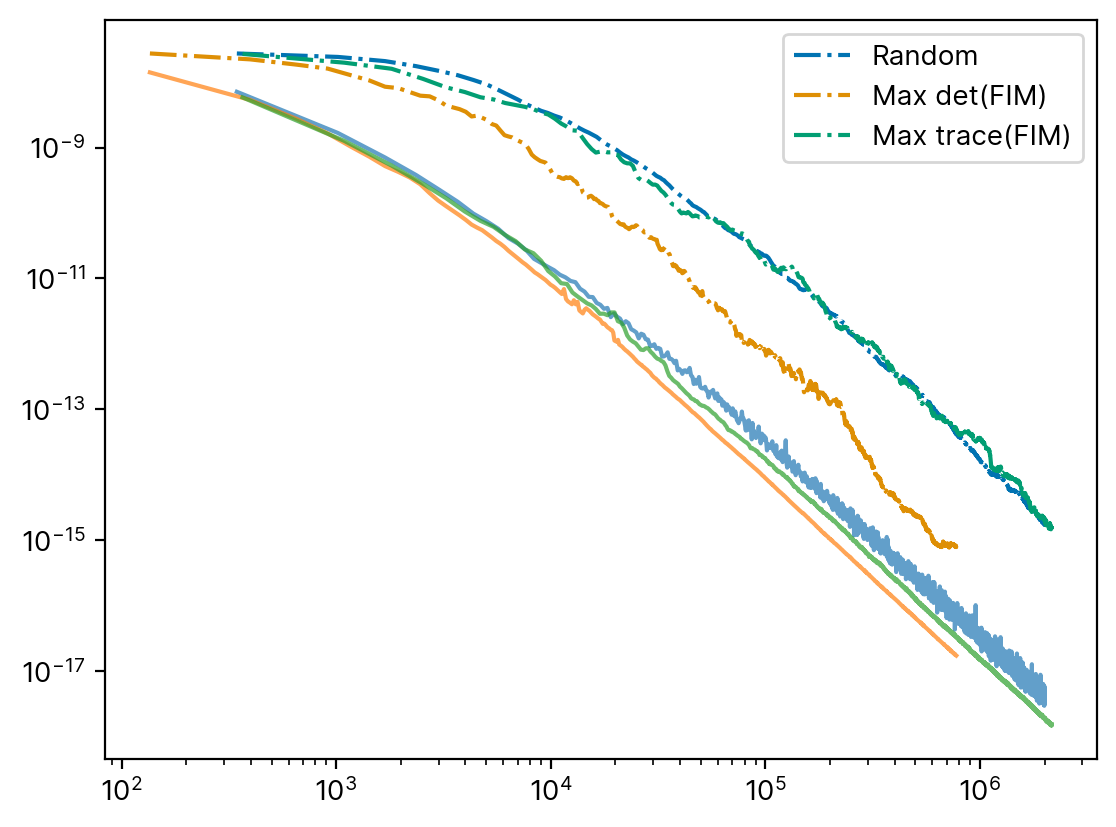

In [228]:
fig, ax = plt.subplots(dpi=200)


colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
]

for i in range(3, 6, 1):
    ax.plot(
        results_binned[i]["cumtimes"],
        results_binned[i]["covdet"][:],
        "-.",
        label=legend_array[i],
    )

    ax.plot(
        results_binned[i]["cumtimes"],
        jax.vmap(
            (
                lambda T, EF, I: 1
                / T**3
                / jnp.linalg.det((1 * (1 * EF + 1 * I / T)))
            ),
            in_axes=(0, 0, None),
        )(
            results_binned[i]["cumtimes"],
            results_binned[i]["fishermeans"],
            I,
        )[
            :,
        ],
        "-",
        ms=3,
        alpha=0.7,
        color=colors[i - 3],
    )
    ax.legend()
    ax.loglog()

    # ax.set_xlim(100, 10000)